# SR1.5 feasibility scorer — release 2018-v2

**Goal:** take indicator files in, produce per-city ranked actions out. One step per cell, no hidden state.

**What changed in 2018-v2 (CC-718).** The v1 scorer let a single city measurement earn weight once per conceptual pathway it was bridged to. `poverty_rate` was bridged to `cost-effectiveness`, `distributional_effects` and `inclusiveness`, so on Public transport it moved the action score three times over — review feedback on the City Fit report flagged exactly this, as both a double count and something a reader could not follow.

**The rule this release adopts: one city indicator, one channel.** Each city indicator now reaches an action score through at most one SR1.5 indicator. Six bridge rows were retired to make that true and one was re-issued on a different channel; the retired rows stay in `sr15_indicator_to_city_indicator.csv` with their literature lineage and a note saying why, so nothing is lost from the record. The scorer enforces the rule as an assertion rather than trusting the dictionary, so a future bridge that reintroduces repetition fails the notebook instead of silently double-counting.

## Steps

1. Setup — paths and parameters
2. Load inputs — four CSV files
3. Reference tables — option families and quintile-to-capacity mapping
4. Build the cell bridge — one row per (option × dimension × indicator × city_bridge); **writes to disk**
5. Define `score_one(action_id, locode)` — the scoring function
6. Score every action for every city
7. Save ranked outputs
8. Regression checks — the invariants CC-718 requires
9. Before/after sensitivity against the 2018 release
10. Full provenance chain
11. API example payload
12. Findings

## The scoring math

For each (action, city), for each SR1.5 A/C cell:

```
sr15_signal      = +1 if C (supportive)  |  -1 if A (barrier)
city_capacity    = QUINT[city's bucket for the bridge's indicator]   # 0.0 - 1.0
bridge_contrib   = bridge_sign x (2 x city_capacity - 1)             # -1 to +1
cell_score       = (sr15_signal + mean(bridge_contribs)) / 2         # if bridges exist
cell_score_01    = (cell_score + 1) / 2                              # 0.0 - 1.0
```

Raw action score = mean over dimensions of (mean `cell_score_01` within each dimension).

Final action score shrinks the raw score toward 0.5 by the action's `match_strength`:

```
strength_weight  = STRENGTH_WEIGHT[match_strength]   # direct=1.0, partial=0.95, cross_cutting=0.9, weak=0.85, no_match=0.0
action_score     = 0.5 + strength_weight x (raw_score - 0.5)
```

The arithmetic is unchanged from v1. The whole of CC-718 lives in the bridge dictionary, which is the point: there is no weighting step to justify, because no indicator is ever counted twice.

## The one-channel rule (CC-718)

**Why not weight the repeated pathways instead.** An earlier draft of this release kept all three poverty pathways and normalised their combined weight down to what the strongest single pathway earned. It was arithmetically sound and it did stop the double count, but it answered the reviewer's question with a number nobody could defend: asked *how much should poverty contribute through inclusiveness*, the honest answer is that the scorer's weights are face-valid defaults, not estimates. Any weight invites a question the methodology cannot answer. Removing the repetition removes the question.

**How the surviving channel was chosen — evidence strength, not influence.** Picking the channel that carried the most weight would have been circular: weight here is an artifact of how many A/C cells a dimension happens to contain, so the "biggest" channel is just the one in the sparsest dimension. Each bridge instead kept the channel with the strongest empirical lineage, and the abandoned cells fall back to the IPCC global verdict, which is a statement a reader can follow: the IPCC finding stands, and we have no city-level evidence bearing on it.

| City indicator | Channel kept | Channels retired | Reason |
|---|---|---|---|
| `poverty_rate` | `cost-effectiveness` | `distributional_effects`, `inclusiveness` | Energy-poverty literature on binding liquidity constraints (Bouzarovski; Bird & Hernández; Reames) is a measured mechanism; the other two rest on normative claims about who bears cost. |
| `employment_manufacturing` | `employment_productivity` | `institutional_capacity`, `technical_scalability` | All three rationales restated one fact — an industrial workforce is present. `employment_productivity` is the channel the rest of the sector-employment family already used. |
| `employment_in_transport_and_logistics` | `employment_productivity` | `institutional_capacity` | Same family rule. |
| `employment_electricity_gas` | `employment_productivity` | `institutional_capacity` (moved, not dropped) | Was the family's lone exception; moving it means one rule covers all four sector-employment indicators. |

**What it costs.** `institutional_capacity` was the only institutional channel carrying city bridges, and all three of its bridges were the sector-employment rows. The Institutional dimension is therefore now entirely SR1.5 prior: it contributes to the score but no longer discriminates between cities. That is a real loss of signal, taken deliberately in exchange for a methodology with no unexplainable weights. A governance index (WGI or similar) is the right way to give that dimension city-level discrimination back, and is the standing recommendation in `review.md`.

**Bridges that are still multi-channel but dormant.** Six indicators still appear on two SR1.5 indicators in the dictionary — `home_ownership`, `renter_share`, `indigenous_identification_rate`, `primary_forest_share`, `secondary_forest_share`, `wetland_share`. None of them currently repeats *within a single action*, because the two channels never both carry an A/C verdict for the same option. They are left in place rather than pre-emptively curated. Step 8 asserts the invariant against the real cell set, so if AR6 or AR7 upgrades a code and activates one of these pairs, the notebook fails and forces the curation decision then.

## Step 1 — Setup

Paths and parameters. Change `CITY_INDICATORS_PATH` to score a different set of cities.

In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd()             # notebook lives in releases/2018-v2/
DATA = ROOT / 'data'
OUT  = ROOT / 'sample'

ACTIONS_PATH           = DATA / 'actions_to_sr15_mapping.csv'
PER_CELL_PATH          = DATA / 'sr15_feasibility_per_cell.csv'
BRIDGES_PATH           = DATA / 'sr15_indicator_to_city_indicator.csv'
CITY_INDICATORS_PATH   = OUT  / 'test_cities_indicators.csv'

# Derived (written by this notebook)
CELL_BRIDGE_PATH       = DATA / 'sr15_cell_bridge.csv'
CHAIN_PATH             = DATA / 'scoring_chain.csv'
API_EXAMPLE_PATH       = DATA / 'api' / 'example_response.json'
RANKED_ACTIONS_PATH    = OUT  / 'test_cities_ranked_actions_by_locode.csv'
RANKED_PER_CELL_PATH   = OUT  / 'test_cities_ranked_actions_per_cell.csv'
LEGACY_CHAIN_PATH      = OUT  / 'scoring_chain_full.csv'

RELEASE_ID = '2018-v2'

# Bridge-dictionary status values (CC-718).
#   active         - in force in both the 2018 release and this one
#   retired_cc718  - was in force in 2018; retired here so its city indicator keeps one channel
#   added_cc718    - new here; the employment_electricity_gas row re-issued on employment_productivity
STATUS_LIVE = ('active', 'added_cc718')   # what this release scores with
STATUS_V1   = ('active', 'retired_cc718') # what the 2018 release scored with, for the comparison in Step 9

# Mapping-confidence weights. The headline action score shrinks toward 0.5 by this weight:
#     action_score = 0.5 + STRENGTH_WEIGHT[match_strength] x (raw_score - 0.5)
# Rationale: a `weak` mapping borrows the SR1.5 option prior less reliably than a `direct` mapping,
# so its score should hedge toward neutral. Direct gets full weight; no_match collapses to 0.5.
STRENGTH_WEIGHT = {
    'direct':        1.00,
    'partial':       0.95,
    'cross_cutting': 0.90,
    'weak':          0.85,
    'no_match':      0.00,
}

print(f'release : {RELEASE_ID}')

release : 2018-v2


## Step 2 — Load inputs

Four CSV files. Each is one logical input. The bridge dictionary now carries a `status` column: `active` rows are in force, `retired_cc718` rows were in force in the 2018 release and are kept for their literature lineage and for the before/after comparison, and the single `added_cc718` row is the sector-employment bridge re-issued on a different channel.

In [2]:
actions      = pd.read_csv(ACTIONS_PATH)               # action_id -> sr15_options (102 actions)
per_cell     = pd.read_csv(PER_CELL_PATH)              # SR1.5 priors: option x dimension x indicator -> A/B/C/NA/NE/LE
bridges_all  = pd.read_csv(BRIDGES_PATH)               # SR1.5 indicator + scope -> city_indicator + sign + status
city_df      = pd.read_csv(CITY_INDICATORS_PATH)       # city x attribute_type -> attribute_category

bridges    = bridges_all[bridges_all.status.isin(STATUS_LIVE)]   # this release
bridges_v1 = bridges_all[bridges_all.status.isin(STATUS_V1)]     # the 2018 release, for Step 9

print(f'actions     : {len(actions):>5d} rows  ({actions.action_id.nunique()} unique action_ids)')
print(f'per_cell    : {len(per_cell):>5d} rows  ({per_cell.option.nunique()} SR1.5 options x {per_cell.dimension.nunique()} dimensions)')
print(f'city_df     : {len(city_df):>5d} rows  ({city_df.locode.nunique()} cities x {city_df.attribute_type.nunique()} indicators)')
print()
print('bridge dictionary by status:')
print(bridges_all.status.value_counts().to_string())
bridges_all[bridges_all.status != 'active'][['sr15_indicator','city_indicator','sign','scope','status']].reset_index(drop=True)

actions     :   102 rows  (102 unique action_ids)
per_cell    :   547 rows  (27 SR1.5 options x 6 dimensions)
city_df     :   330 rows  (12 cities x 34 indicators)

bridge dictionary by status:
status
active           48
retired_cc718     6
added_cc718       1


,sr15_indicator,city_indicator,sign,scope,status
0,distributional_effects,poverty_rate,-1,all,retired_cc718
1,technical_scalability,employment_manufacturing,1,industrial,retired_cc718
2,institutional_capacity,employment_in_transport_and_logistics,1,transport,retired_cc718
3,institutional_capacity,employment_manufacturing,1,industrial,retired_cc718
4,institutional_capacity,employment_electricity_gas,1,energy_supply,retired_cc718
5,inclusiveness,poverty_rate,-1,all,retired_cc718
6,employment_productivity,employment_electricity_gas,1,energy_supply,added_cc718


## Step 3 — Reference tables

Two small lookup dicts:

- `OPTION_FAMILY`: every SR1.5 option belongs to one scope family (`energy_supply`, `transport`, `buildings`, etc.). Bridges with `scope=all` apply to every option; bridges with a specific scope only apply to options in that family.
- `QUINT`: the city's categorical bucket maps to a capacity number between 0 and 1. `very low` -> 0, `very high` -> 1.

In [3]:
OPTION_FAMILY = {
    # energy supply
    'Wind (on-shore & off-shore)':'energy_supply','Solar PV':'energy_supply','Bioenergy':'energy_supply',
    'Electricity storage':'energy_supply','Power sector CCS':'energy_supply','Nuclear energy':'energy_supply',
    'Smart grids':'energy_supply','BECCS':'energy_supply','DACCS':'energy_supply',
    # waste / dietary
    'Reduced food wastage':'waste','Dietary shifts':'waste',
    # nature-based
    'Sustainable intensification':'sustainable_intensification',  # split out so pasture/cropland bridges target livestock/crop options without firing on afforestation
    'Afforestation & reforestation':'nbs',
    'Soil carbon sequestration & biochar':'nbs','Enhanced weathering':'nbs',
    # cross-cutting
    'Land-use & urban planning':'cross_cutting',
    # transport
    'Electric cars and buses':'transport','Sharing schemes':'transport','Public transport':'transport',
    'Non-motorised transport':'transport','Aviation & shipping':'transport',
    # buildings
    'Efficient appliances':'buildings','Low/zero-energy buildings':'buildings',
    # industrial
    'Energy efficiency':'industrial','Bio-based & circularity':'industrial',
    'Electrification & hydrogen':'industrial','Industrial CCS':'industrial',
}

QUINT = {'very low':0.0, 'low':0.25, 'medium':0.5, 'high':0.75, 'very high':1.0}

print(f'OPTION_FAMILY covers {len(OPTION_FAMILY)} SR1.5 options across {len(set(OPTION_FAMILY.values()))} scope families')
print(f'QUINT mapping: {QUINT}')

OPTION_FAMILY covers 27 SR1.5 options across 8 scope families
QUINT mapping: {'very low': 0.0, 'low': 0.25, 'medium': 0.5, 'high': 0.75, 'very high': 1.0}


## Step 4 — Build the cell bridge

Walk every A/C cell in `per_cell` and attach the city bridges that apply (matching `indicator` + scope in {`all`, `option_family`}). Cells with code B/NE/LE/NA get no city adjustment (per the A/C rule in `review.md`).

**Writes `sr15_cell_bridge.csv`** from the live dictionary. The same builder also produces the 2018 cell bridge in memory, which Step 9 scores against to measure what the rule moved.

The cell also asserts that no `(option, indicator)` cell attaches the same `city_indicator` twice through different scopes — within-cell repetition would be a second, quieter form of the CC-718 double count that the per-cell mean would hide.

In [4]:
def build_cell_bridge(bridge_dict):
    """Attach scope-matching city bridges to every A/C cell. Returns one row per cell x bridge."""
    real = bridge_dict[bridge_dict.city_indicator != '(option-level constant)']
    rows = []
    for _, cell in per_cell.iterrows():
        option, indicator, code_, dimension = cell.option, cell.indicator, cell.code, cell.dimension
        family = OPTION_FAMILY.get(option, '?')
        if code_ not in ('A', 'C'):            # no directional evidence, no city adjustment
            rows.append({'option':option,'dimension':dimension,'indicator':indicator,'sr15_code':code_,
                         'option_family':family,'city_indicator':f'(SR1.5 code {code_}: no directional evidence)',
                         'sign':0,'scope':''})
            continue
        matches = real[(real.sr15_indicator == indicator) & (real.scope.isin(['all', family]))]
        if matches.empty:
            rows.append({'option':option,'dimension':dimension,'indicator':indicator,'sr15_code':code_,
                         'option_family':family,'city_indicator':'(no scope-matching bridge)',
                         'sign':0,'scope':''})
        else:
            for _, b in matches.iterrows():
                rows.append({'option':option,'dimension':dimension,'indicator':indicator,'sr15_code':code_,
                             'option_family':family,'city_indicator':b.city_indicator,
                             'sign':int(b.sign),'scope':b.scope})
    return pd.DataFrame(rows)

def build_index(cb):
    """(option, indicator) -> [(city_indicator, sign), ...] for live bridges only."""
    ix = {}
    for r in cb[cb.sign != 0].itertuples():
        ix.setdefault((r.option, r.indicator), []).append((r.city_indicator, int(r.sign)))
    return ix

cell_bridge    = build_cell_bridge(bridges)
cell_bridge_v1 = build_cell_bridge(bridges_v1)
BRIDGE_INDEX    = build_index(cell_bridge)
BRIDGE_INDEX_V1 = build_index(cell_bridge_v1)

# A city_indicator may attach to a given cell at most once
_dupes = cell_bridge[cell_bridge.sign != 0].groupby(['option','indicator','city_indicator']).size()
_dupes = _dupes[_dupes > 1]
assert _dupes.empty, f'city_indicator attached more than once to the same cell:\n{_dupes}'

cell_bridge.to_csv(CELL_BRIDGE_PATH, index=False)

active = (cell_bridge.sign != 0).sum()
print(f'Wrote {CELL_BRIDGE_PATH.name}: {len(cell_bridge)} rows ({active} with active city bridge)')
print(f'  2018 baseline for comparison: {(cell_bridge_v1.sign != 0).sum()} active bridge rows')
print(f'Within-cell duplicate bridges: 0 (asserted)')

# A/C cell census - the counts review.md quotes. Bridge ROWS and distinct CELLS are different
# numbers, because one A/C cell can carry several different city indicators.
_ac      = per_cell[per_cell.code.isin(['A','C'])][['option','indicator']].drop_duplicates()
_bridged = cell_bridge[cell_bridge.sign != 0][['option','indicator']].drop_duplicates()
print()
print(f'A/C cells: {len(_ac)} of {len(per_cell)} ({len(_ac)/len(per_cell):.0%}) eligible for city adjustment')
print(f'  with a scope-matched bridge : {len(_bridged)} cells, carrying {active} bridge rows')
print(f'  prior-only (no bridge)      : {len(_ac) - len(_bridged)} cells')
cell_bridge[cell_bridge.sign != 0].scope.value_counts().rename('active bridges').to_frame()

Wrote sr15_cell_bridge.csv: 596 rows (108 with active city bridge)
  2018 baseline for comparison: 127 active bridge rows
Within-cell duplicate bridges: 0 (asserted)

A/C cells: 261 of 547 (48%) eligible for city adjustment
  with a scope-matched bridge : 59 cells, carrying 108 bridge rows
  prior-only (no bridge)      : 202 cells


,active bridges
scope,
all,65
energy_supply,12
buildings,11
nbs,10
transport,6
sustainable_intensification,2
industrial,2


## Step 5 — Score one (action, city) pair

Pure — no globals beyond the input dataframes and the two module-level lookups. `bridge_index` is a parameter so the same function scores this release and the 2018 baseline, which is what makes the Step 9 comparison a real before/after rather than a re-derivation.

In [5]:
def score_one(action_id, locode, actions, per_cell, bridge_index, city_df):
    """Return (raw_score, cells_df, bridge_detail_df) for one action x one city.

    cells_df        : one row per A/C cell, with cell_score_01
    bridge_detail_df: one row per live (cell, city_indicator) bridge - the diagnostic CSV reads this
    """
    empty = (None, pd.DataFrame(), pd.DataFrame())

    action_row = actions[actions.action_id == action_id].iloc[0]
    options = [o for o in str(action_row.sr15_options).split('|') if not o.startswith('(')]
    if not options:
        return empty

    city_data = city_df[city_df.locode == locode]
    city_capacity = {r.attribute_type: QUINT[r.attribute_category]
                     for _, r in city_data.iterrows() if r.attribute_category in QUINT}
    city_bucket   = {r.attribute_type: r.attribute_category for _, r in city_data.iterrows()}

    action_cells = per_cell[per_cell.option.isin(options) & per_cell.code.isin(['A', 'C'])]
    if action_cells.empty:
        return empty

    live, cell_scores = [], []
    for cell_ix, cell in action_cells.iterrows():
        sr15_signal = +1 if cell.code == 'C' else -1
        b = [(ci, sg) for ci, sg in bridge_index.get((cell.option, cell.indicator), [])
             if ci in city_capacity]
        contribs = []
        for ci, sg in b:
            contrib = sg * (2 * city_capacity[ci] - 1)
            contribs.append(contrib)
            live.append({'cell_ix': cell_ix, 'option': cell.option, 'dimension': cell.dimension,
                         'indicator': cell.indicator, 'sr15_code': cell.code,
                         'city_indicator': ci, 'sign': sg,
                         'city_bucket': city_bucket.get(ci, ''),
                         'city_capacity': city_capacity[ci], 'contribution': contrib})
        cell_score = ((sr15_signal + sum(contribs) / len(contribs)) / 2) if contribs else sr15_signal
        cell_scores.append({'cell_ix': cell_ix, 'option': cell.option, 'dim': cell.dimension,
                            'indicator': cell.indicator, 'code': cell.code,
                            'n_bridges': len(contribs), 'cell_score_01': (cell_score + 1) / 2})

    cells = pd.DataFrame(cell_scores)
    raw_score = cells.groupby('dim')['cell_score_01'].mean().mean()
    return raw_score, cells, pd.DataFrame(live)


# Smoke test: Public transport was the worst CC-718 case (poverty_rate in all three channels)
_r2, _c2, _d2 = score_one('icare_0117', 'CL ZAL', actions, per_cell, BRIDGE_INDEX,    city_df)
_r1, _c1, _d1 = score_one('icare_0117', 'CL ZAL', actions, per_cell, BRIDGE_INDEX_V1, city_df)
print('icare_0117 (Improve public transport systems) for Valdivia')
print(f'  raw score, 2018   : {_r1:.4f}   ({(_d1.city_indicator == "poverty_rate").sum()} poverty_rate bridges)')
print(f'  raw score, 2018-v2: {_r2:.4f}   ({(_d2.city_indicator == "poverty_rate").sum()} poverty_rate bridge)')
_d2[['dimension','indicator','city_indicator','sign','city_bucket','contribution']].reset_index(drop=True)

icare_0117 (Improve public transport systems) for Valdivia
  raw score, 2018   : 0.9479   (3 poverty_rate bridges)
  raw score, 2018-v2: 0.9653   (1 poverty_rate bridge)


,dimension,indicator,city_indicator,sign,city_bucket,contribution
0,economic,cost-effectiveness,median_household_income,1,very high,1.0
1,economic,cost-effectiveness,poverty_rate,-1,very low,1.0
2,economic,employment_productivity,unemployment_rate,1,medium,0.0
3,economic,employment_productivity,employment_in_transport_and_logistics,1,medium,0.0
4,socio_cultural,inclusiveness,disability_prevalence,-1,low,0.5
5,socio_cultural,inclusiveness,indigenous_identification_rate,-1,high,-0.5
6,socio_cultural,human_capabilities,mean_years_schooling,1,very high,1.0
7,socio_cultural,human_capabilities,literacy_rate,1,very high,1.0
8,geophysical,physical_feasibility,urban_built_share,1,medium,0.0


## Step 6 — Score every action for every city

Loop over (city x action). Skip pairs that produce `None` (action has no scoreable SR1.5 mapping). The 2018 score is computed in the same pass so Step 9 can report the shift without a second run.

In [6]:
cities = city_df[['locode', 'region_name']].drop_duplicates().sort_values('locode').reset_index(drop=True)
print(f'Scoring {actions.action_id.nunique()} actions x {len(cities)} cities = {actions.action_id.nunique() * len(cities)} pairs')

ranked_rows, per_cell_rows = [], []

for _, city in cities.iterrows():
    locode, region = city.locode, city.region_name

    for aid in actions.action_id:
        raw_score, cells, detail = score_one(aid, locode, actions, per_cell, BRIDGE_INDEX, city_df)
        if raw_score is None:
            continue
        raw_v1, cells_v1, _ = score_one(aid, locode, actions, per_cell, BRIDGE_INDEX_V1, city_df)

        a = actions[actions.action_id == aid].iloc[0]
        dim_scores    = cells.groupby('dim')['cell_score_01'].mean().to_dict()
        dim_scores_v1 = cells_v1.groupby('dim')['cell_score_01'].mean().to_dict()

        # Mapping-confidence shrinkage on the headline score.
        # Per-dimension scores stay raw (they describe IPCC+city evidence, independent of mapping confidence).
        sw = STRENGTH_WEIGHT.get(a.match_strength, 0.0)

        ranked_rows.append({
            'locode': locode, 'region_name': region, 'action_id': aid, 'action_name': a.action_name,
            'primary_outcome': a.primary_outcome, 'primary_channel': a.primary_channel,
            'sr15_options': a.sr15_options, 'match_strength': a.match_strength, 'strength_weight': sw,
            'n_ac_cells': len(cells), 'n_dims_scored': len(dim_scores),
            'econ': round(dim_scores.get('economic',       float('nan')), 3),
            'tech': round(dim_scores.get('technological',  float('nan')), 3),
            'inst': round(dim_scores.get('institutional',  float('nan')), 3),
            'soc':  round(dim_scores.get('socio_cultural', float('nan')), 3),
            'env':  round(dim_scores.get('environmental',  float('nan')), 3),
            'geo':  round(dim_scores.get('geophysical',    float('nan')), 3),
            'raw_score': round(raw_score, 3),
            'score': round(0.5 + sw * (raw_score - 0.5), 3),
            'n_city_bridges': len(detail),
            'score_v1': round(0.5 + sw * (raw_v1 - 0.5), 3),
            'score_delta_vs_v1': round(sw * (raw_score - raw_v1), 4),
        })

        # Per-cell diagnostic. Every defined bridge gets a row, including bridges the city
        # has no data for - those carry '(no city data)'.
        cell_meta  = cells.set_index('cell_ix')
        live_by_ix = {ix: g for ix, g in detail.groupby('cell_ix')} if len(detail) else {}
        for cell_ix, c in cell_meta.iterrows():
            base = {'locode': locode, 'action_id': aid, 'sr15_option': c.option, 'dimension': c['dim'],
                    'indicator': c.indicator, 'sr15_code': c.code,
                    'cell_score_01': round(c.cell_score_01, 3)}
            defined = BRIDGE_INDEX.get((c.option, c.indicator), [])
            if not defined:
                per_cell_rows.append({**base, 'city_indicator': '(no bridge)', 'sign': 0,
                                      'city_bucket': '', 'city_capacity': '', 'indicator_contribution': ''})
                continue
            live = live_by_ix.get(cell_ix, pd.DataFrame())
            live_by_ci = {r.city_indicator: r for _, r in live.iterrows()} if len(live) else {}
            for ci, sg in defined:
                b = live_by_ci.get(ci)
                if b is None:
                    per_cell_rows.append({**base, 'city_indicator': ci, 'sign': int(sg),
                                          'city_bucket': '(no city data)', 'city_capacity': '',
                                          'indicator_contribution': ''})
                    continue
                per_cell_rows.append({**base, 'city_indicator': b.city_indicator, 'sign': int(b.sign),
                                      'city_bucket': b.city_bucket, 'city_capacity': b.city_capacity,
                                      'indicator_contribution': round(b.contribution, 3)})

print(f'Done: {len(ranked_rows)} (action x city) pairs scored, {len(per_cell_rows)} per-cell diagnostic rows')

Scoring 102 actions x 12 cities = 1224 pairs


Done: 1032 (action x city) pairs scored, 11880 per-cell diagnostic rows


## Step 7 — Save ranked outputs

Per-city ranking (descending by score) and the per-cell diagnostic. The diagnostic is the file to open when you want to see why a particular action got its score; its schema is unchanged from the 2018 release, because the one-channel rule needed no new columns.

In [7]:
ranked = (pd.DataFrame(ranked_rows)
          .sort_values(['locode', 'score'], ascending=[True, False])
          .reset_index(drop=True))
ranked.to_csv(RANKED_ACTIONS_PATH, index=False)

per_cell_df = pd.DataFrame(per_cell_rows)
per_cell_df.to_csv(RANKED_PER_CELL_PATH, index=False)

print(f'Wrote {RANKED_ACTIONS_PATH.name}: {len(ranked)} rows')
print(f'Wrote {RANKED_PER_CELL_PATH.name}: {len(per_cell_df)} rows')
ranked.head(8)[['locode','action_id','action_name','match_strength','raw_score','score','score_v1','score_delta_vs_v1']]

Wrote test_cities_ranked_actions_by_locode.csv: 1032 rows
Wrote test_cities_ranked_actions_per_cell.csv: 11880 rows


,locode,action_id,action_name,match_strength,raw_score,score,score_v1,score_delta_vs_v1
0,CL CRR,icare_0001,Improve heat and energy recovery,direct,0.969,0.969,0.958,0.0104
1,CL CRR,icare_0009,Deploy cogeneration systems in industries,direct,0.969,0.969,0.958,0.0104
2,CL CRR,icare_0034,Improve Fuel Supply Systems for Industrial Hea...,direct,0.969,0.969,0.958,0.0104
3,CL CRR,icare_0035,Enhance industrial energy efficiency processes,direct,0.969,0.969,0.958,0.0104
4,CL CRR,icare_0071,Increase efficiency of industrial furnaces and...,direct,0.969,0.969,0.958,0.0104
5,CL CRR,icare_0072,Improve Heat Recovery and Reuse through Heat E...,direct,0.969,0.969,0.958,0.0104
6,CL CRR,icare_0074,Adopt industrial energy efficiency technologies,direct,0.969,0.969,0.958,0.0104
7,CL CRR,ipcc_0024,Improve material utilization efficiency in pro...,direct,0.969,0.969,0.958,0.0104


## Step 8 — Regression checks (CC-718)

Five assertions, each covering one acceptance criterion. They run over the whole catalogue, not a sample, and the notebook refuses to export if any fails.

1. **One channel per indicator.** For every action, no city indicator is bridged to more than one A/C `(dimension, global_indicator)` channel. This is the rule itself, asserted against the real cell set rather than trusted from the dictionary — so a future bridge that reintroduces repetition, or an AR6/AR7 code upgrade that activates one of the dormant pairs, fails here.
2. **The 2018 baseline reproduces.** Scoring with the reconstructed 2018 bridge index returns the committed `2018` ranked output exactly, which is what makes the Step 9 before/after a true comparison.
3. **Nothing changed except the curated rows.** Every bridge present in 2018 but not now traces to a `retired_cc718` dictionary row, and every bridge present now but not in 2018 traces to the single `added_cc718` row. No other bridge appeared, vanished or changed sign, so the whole difference between the releases is the curation.
4. **Both signs behave correctly.** Scoring a mirrored city (every bucket flipped `very low` <-> `very high`) negates each action's city adjustment exactly, so positive- and negative-sign bridges are handled symmetrically.
5. **Score bounds hold.** All scores stay in [0, 1].

In [8]:
import numpy as np

TOL = 1e-9
checks = []

# --- Check 1: one channel per city indicator, per action ---
violations = []
for _, a in actions.iterrows():
    options = [o for o in str(a.sr15_options).split('|') if not o.startswith('(')]
    cells = per_cell[per_cell.option.isin(options) & per_cell.code.isin(['A','C'])]
    seen = {}
    for _, c in cells.iterrows():
        for ci, _sg in BRIDGE_INDEX.get((c.option, c.indicator), []):
            seen.setdefault(ci, set()).add((c.dimension, c.indicator))
    for ci, chans in seen.items():
        if len(chans) > 1:
            violations.append((a.action_id, ci, sorted(chans)))
assert not violations, f'city indicator reaches {len(violations)} action(s) through more than one channel: {violations[:5]}'
checks.append(('1. one channel per indicator',
               f'{actions.action_id.nunique()} actions checked, 0 indicators on more than one A/C channel', 'PASS'))

# --- Check 2: the 2018 baseline reproduces exactly ---
baseline = Path('..') / '2018' / 'sample' / 'test_cities_ranked_actions_by_locode.csv'
if baseline.exists():
    v1_committed = pd.read_csv(baseline).set_index(['locode','action_id']).score
    v1_here      = ranked.set_index(['locode','action_id']).score_v1
    diff = (v1_committed - v1_here).abs().max()
    assert diff < 5e-4, f'2018 baseline did not reproduce, max diff {diff}'
    checks.append(('2. 2018 baseline reproduces', f'max diff {diff:.1e} over {len(v1_here)} pairs', 'PASS'))
else:
    checks.append(('2. 2018 baseline reproduces', 'skipped - releases/2018 sample not present (gitignored)', 'SKIP'))

# --- Check 3: the only difference between the releases is the curated rows ---
retired_pairs = set(map(tuple, bridges_all[bridges_all.status == 'retired_cc718'][['sr15_indicator','city_indicator']].values))
added_pairs   = set(map(tuple, bridges_all[bridges_all.status == 'added_cc718'][['sr15_indicator','city_indicator']].values))

def bridge_set(cb):
    live = cb[cb.sign != 0]
    return set(map(tuple, live[['option','indicator','city_indicator','sign']].values))

only_v1 = bridge_set(cell_bridge_v1) - bridge_set(cell_bridge)
only_v2 = bridge_set(cell_bridge)    - bridge_set(cell_bridge_v1)
bad_lost   = [b for b in only_v1 if (b[1], b[2]) not in retired_pairs]
bad_gained = [b for b in only_v2 if (b[1], b[2]) not in added_pairs]
assert not bad_lost,   f'bridges disappeared that were not retired: {bad_lost[:5]}'
assert not bad_gained, f'bridges appeared that were not added: {bad_gained[:5]}'
assert not (bridge_set(cell_bridge) ^ bridge_set(cell_bridge_v1)) - only_v1 - only_v2
checks.append(('3. only the curated rows differ',
               f'{len(only_v1)} cell bridges retired, {len(only_v2)} added, 0 other differences', 'PASS'))

# --- Check 4: sign symmetry via a mirrored city ---
# NEUTRAL is the reference: every bucket 'medium', so every bridge contributes exactly 0.
# MIRROR flips each of the probe city's buckets about that midpoint, which must negate the
# whole city adjustment - for negative-sign bridges as much as positive ones.
MIRROR = {'very low':'very high','low':'high','medium':'medium','high':'low','very high':'very low'}
probe = 'CL ZAL'
base = city_df[city_df.locode == probe]

mdf = base.copy(); mdf['attribute_category'] = mdf.attribute_category.map(lambda b: MIRROR.get(b, b))
mdf['locode'] = 'MIRROR'
ndf = base.copy(); ndf['attribute_category'] = 'medium'; ndf['locode'] = 'NEUTRAL'
probe_cities = pd.concat([city_df, mdf, ndf], ignore_index=True)

sign_err = 0.0
for aid in actions.action_id:
    ra, _, _ = score_one(aid, probe,     actions, per_cell, BRIDGE_INDEX, probe_cities)
    if ra is None:
        continue
    rm, _, _ = score_one(aid, 'MIRROR',  actions, per_cell, BRIDGE_INDEX, probe_cities)
    rn, _, _ = score_one(aid, 'NEUTRAL', actions, per_cell, BRIDGE_INDEX, probe_cities)
    sign_err = max(sign_err, abs((ra - rn) + (rm - rn)))
assert sign_err < TOL, f'sign asymmetry, max error {sign_err}'
checks.append(('4. sign symmetry (mirrored city)', f'max error {sign_err:.2e} across {actions.action_id.nunique()} actions', 'PASS'))

# --- Check 5: bounds ---
assert ranked.score.between(0, 1).all() and ranked.raw_score.between(0, 1).all(), 'score out of [0,1]'
checks.append(('5. score bounds [0,1]', f'{len(ranked)} rows', 'PASS'))

pd.DataFrame(checks, columns=['check','evidence','result'])

,check,evidence,result
0,1. one channel per indicator,"102 actions checked, 0 indicators on more than...",PASS
1,2. 2018 baseline reproduces,max diff 0.0e+00 over 1032 pairs,PASS
2,3. only the curated rows differ,"23 cell bridges retired, 4 added, 0 other diff...",PASS
3,4. sign symmetry (mirrored city),max error 4.44e-16 across 102 actions,PASS
4,"5. score bounds [0,1]",1032 rows,PASS


## Step 9 — Before/after sensitivity against the 2018 release

What retiring the six bridges actually moved. The issue named Public transport, Non-motorised transport and one non-poverty repeated indicator (`employment_manufacturing`) as the cases to record.

This is a larger shift than a reweighting would have been, and deliberately so: when a retired bridge was a cell's only bridge, that cell falls back to the SR1.5 prior rather than merely losing weight.

In [9]:
moved = ranked[ranked.score_delta_vs_v1 != 0]
print(f'{len(moved)} of {len(ranked)} (action x city) rows moved, across '
      f'{moved.action_id.nunique()} of {ranked.action_id.nunique()} scoreable actions')
print(f'delta range: {moved.score_delta_vs_v1.min():+.4f} to {moved.score_delta_vs_v1.max():+.4f}, '
      f'mean |delta| {moved.score_delta_vs_v1.abs().mean():.4f}')

# Which dimensions absorbed the change?
v1_dims = []
for _, city in cities.iterrows():
    for aid in actions.action_id:
        r1, c1, _ = score_one(aid, city.locode, actions, per_cell, BRIDGE_INDEX_V1, city_df)
        if r1 is None:
            continue
        d1 = c1.groupby('dim')['cell_score_01'].mean().round(3).to_dict()
        v1_dims.append({'locode': city.locode, 'action_id': aid, **d1})
v1_dims = pd.DataFrame(v1_dims).set_index(['locode','action_id'])
cur = ranked.set_index(['locode','action_id'])[['econ','tech','inst','soc','env','geo']]
cur.columns = ['economic','technological','institutional','socio_cultural','environmental','geophysical']
cmp_ = cur.join(v1_dims, rsuffix='_v1')
dim_table = pd.DataFrame([
    {'dimension': d,
     'rows_moved': int(((cmp_[d] != cmp_[d+'_v1']) & ~(cmp_[d].isna() & cmp_[d+'_v1'].isna())).sum()),
     'mean_delta': round(float((cmp_[d] - cmp_[d+'_v1']).mean()), 4)}
    for d in cur.columns]).sort_values('rows_moved', ascending=False).reset_index(drop=True)
dim_table

492 of 1032 (action x city) rows moved, across 57 of 86 scoreable actions
delta range: -0.0833 to +0.0625, mean |delta| 0.0200


,dimension,rows_moved,mean_delta
0,economic,305,0.0060
1,technological,160,0.0169
2,institutional,114,-0.0093
3,socio_cultural,54,-0.0004
4,environmental,0,0.0000
5,geophysical,0,0.0000


In [10]:
NAMED = {'icare_0117': 'Public transport',
         'ipcc_0105':  'Non-motorised transport (road space reallocation)',
         'icare_0121': 'Non-motorised transport (bike sharing)',
         'icare_0110': 'employment_manufacturing case (C&D waste)',
         'ipcc_0049':  'employment_manufacturing case (circular economy)'}

named = (ranked[ranked.action_id.isin(NAMED)]
         .assign(case=lambda d: d.action_id.map(NAMED))
         .groupby(['case','action_id'])
         .agg(n_cities=('locode','nunique'),
              mean_v1=('score_v1','mean'), mean_v2=('score','mean'),
              mean_delta=('score_delta_vs_v1','mean'),
              max_abs_delta=('score_delta_vs_v1', lambda s: s.abs().max()))
         .round(4).reset_index())
named

,case,action_id,n_cities,mean_v1,mean_v2,mean_delta,max_abs_delta
0,Non-motorised transport (bike sharing),icare_0121,12,0.9222,0.9413,0.0192,0.0443
1,Non-motorised transport (road space reallocation),ipcc_0105,12,0.9222,0.9413,0.0192,0.0443
2,Public transport,icare_0117,12,0.9058,0.9365,0.0308,0.0625
3,employment_manufacturing case (C&D waste),icare_0110,12,0.2787,0.2565,-0.0221,0.0531
4,employment_manufacturing case (circular economy),ipcc_0049,12,0.2395,0.2134,-0.0260,0.0625


In [11]:
# How many city bridges does each named action still carry, before and after?
rows = []
for aid, case in NAMED.items():
    _, _, d2 = score_one(aid, 'CL ZAL', actions, per_cell, BRIDGE_INDEX,    city_df)
    _, _, d1 = score_one(aid, 'CL ZAL', actions, per_cell, BRIDGE_INDEX_V1, city_df)
    for ci in sorted(set(d1.city_indicator) | set(d2.city_indicator)):
        n1 = int((d1.city_indicator == ci).sum()); n2 = int((d2.city_indicator == ci).sum())
        if n1 != n2:
            rows.append({'case': case, 'action_id': aid, 'city_indicator': ci,
                         'channels_2018': n1, 'channels_2018_v2': n2})
pd.DataFrame(rows).sort_values(['case','city_indicator']).reset_index(drop=True)

,case,action_id,city_indicator,channels_2018,channels_2018_v2
0,Non-motorised transport (bike sharing),icare_0121,poverty_rate,3,1
1,Non-motorised transport (road space reallocation),ipcc_0105,poverty_rate,3,1
2,Public transport,icare_0117,employment_in_transport_and_logistics,2,1
3,Public transport,icare_0117,poverty_rate,3,1
4,employment_manufacturing case (C&D waste),icare_0110,employment_manufacturing,2,0
5,employment_manufacturing case (circular economy),ipcc_0049,employment_manufacturing,2,0


In [12]:
# Rank churn: does the curation reorder the ranking a city would act on?
churn = []
for loc, g in ranked.groupby('locode'):
    g = g.copy()
    g['rank_v2'] = g.score.rank(ascending=False, method='min')
    g['rank_v1'] = g.score_v1.rank(ascending=False, method='min')
    churn.append({'locode': loc,
                  'spearman': g[['score','score_v1']].corr(method='spearman').iloc[0,1],
                  'max_rank_move': int((g.rank_v2 - g.rank_v1).abs().max()),
                  'top10_changed': int(len(set(g.nsmallest(10,'rank_v2').action_id)
                                           ^ set(g.nsmallest(10,'rank_v1').action_id)) / 2)})
churn = pd.DataFrame(churn).round(4)
churn

,locode,spearman,max_rank_move,top10_changed
0,CL CRR,0.9825,20,3
1,CL FUT,0.9866,16,0
2,CL LAN,0.9949,8,0
3,CL LLG,0.9917,11,3
4,CL LUN,0.9936,11,1
5,CL MAF,0.9913,14,0
6,CL MRQ,0.9778,39,0
7,CL PAN,0.9893,15,0
8,CL PAO,0.9935,9,0
9,CL RBU,0.9317,31,4


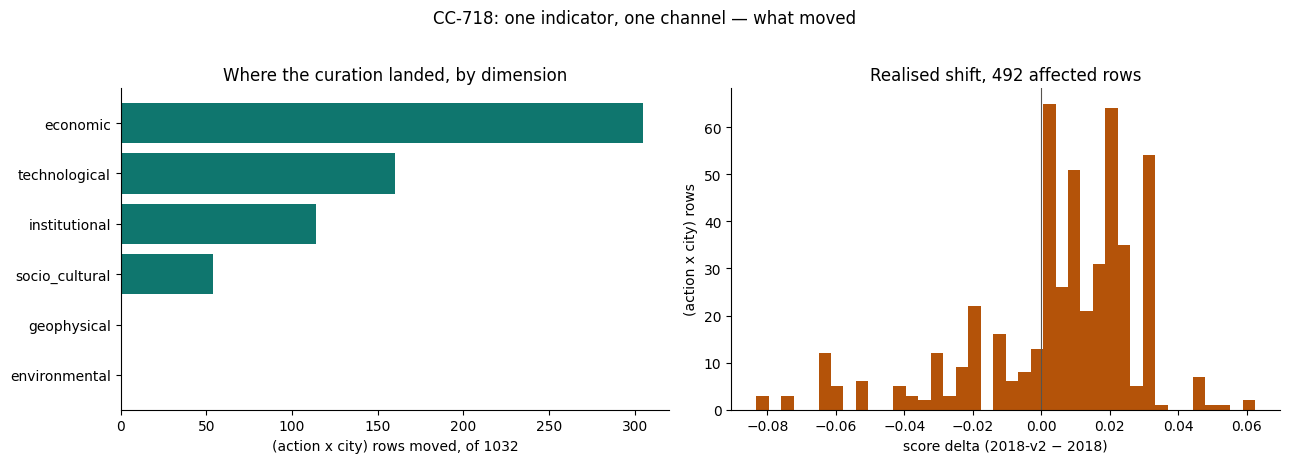

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

d = dim_table.sort_values('rows_moved')
axes[0].barh(d.dimension, d.rows_moved, color='#0f766e')
axes[0].set_xlabel(f'(action x city) rows moved, of {len(ranked)}')
axes[0].set_title('Where the curation landed, by dimension')
axes[0].spines[['top','right']].set_visible(False)

axes[1].hist(moved.score_delta_vs_v1, bins=40, color='#b45309')
axes[1].axvline(0, color='#57534e', lw=0.8)
axes[1].set_xlabel('score delta (2018-v2 − 2018)'); axes[1].set_ylabel('(action x city) rows')
axes[1].set_title(f'Realised shift, {len(moved)} affected rows')
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('CC-718: one indicator, one channel — what moved', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

## Step 10 — Full provenance chain

Walks from action to IPCC SR1.5 mitigation option to SR1.5 dimension+indicator to bridge to city-level indicator in a single flat table. One row per `(action x mitigation_option x dimension x global_indicator x city_indicator)` tuple.

Because of the one-channel rule, a given `(action_id, city_indicator)` pair now appears on exactly one `global_indicator`. That is what makes the City Fit report legible: filter the chain to one city indicator and you get one row per action, not three.

**This step writes two files:**

- `data/scoring_chain.csv` — full schema with `strength_weight`, `country_code` and `release_id`.
- `sample/scoring_chain_full.csv` — legacy 12-column schema consumed by the DB chain-table importer that loads `modelled.action_mitigation_feasibility_chain`. Keep them in lockstep; never edit one without re-running this cell.

In [14]:
action_x_option = []
for _, a in actions.iterrows():
    for opt in [o.strip() for o in str(a.sr15_options).split('|') if not o.strip().startswith('(')]:
        action_x_option.append({'action_id': a.action_id, 'global_mitigation_option': opt,
                                'action_mapping_strength': a.match_strength,
                                'strength_weight': STRENGTH_WEIGHT.get(a.match_strength, 0.0)})
action_x_option = pd.DataFrame(action_x_option)

chain = action_x_option.merge(
    cell_bridge.rename(columns={'option': 'global_mitigation_option'}),
    on='global_mitigation_option', how='left')
chain = chain.rename(columns={'dimension':'feasibility_dimension', 'indicator':'global_indicator',
                              'sr15_code':'global_verdict_code', 'scope':'city_family_scope'})

VERDICT_DESC = {'A':'barrier','B':'neutral','C':'supportive',
                'NA':'not applicable','NE':'no evidence','LE':'limited evidence'}
chain['global_verdict_description'] = chain.global_verdict_code.map(VERDICT_DESC).fillna(chain.global_verdict_code)
chain['city_indicator_direction']   = chain.sign.map({1:'positive', -1:'negative'}).fillna('no directional bridge')

def interpret(row):
    code_ = str(row.global_verdict_code)
    desc  = VERDICT_DESC.get(code_, code_)
    ci    = str(row.city_indicator) if pd.notna(row.city_indicator) else ''
    if code_ in ('B','NE','LE','NA'):
        return (f"IPCC verdict is '{desc}' for this indicator - provides no directional evidence; "
                f"the cell contributes 0 to the dimension score.")
    if ci.startswith('(no scope-matching'):
        return (f"IPCC verdict is '{desc}' but no city-level data bridge is defined for "
                f"'{row.global_indicator}' at sector scope '{row.option_family}'; "
                f"the IPCC prior is used unmodified.")
    if row.sign == 1:
        return (f"Cities with higher {ci} have stronger feasibility for '{row.global_indicator}' "
                f"({row.feasibility_dimension} dimension). Bridge applies to '{row.city_family_scope}' sector. "
                f"IPCC base verdict: {desc}. This is the only channel through which {ci} reaches this action.")
    if row.sign == -1:
        return (f"Cities with higher {ci} have weaker feasibility for '{row.global_indicator}' "
                f"({row.feasibility_dimension} dimension). Bridge applies to '{row.city_family_scope}' sector. "
                f"IPCC base verdict: {desc}. This is the only channel through which {ci} reaches this action.")
    return f'No directional adjustment available for this cell. IPCC base verdict: {desc}.'

chain['interpretation'] = chain.apply(interpret, axis=1)

no_bridge = chain.city_indicator.fillna('').astype(str).str.startswith('(')
chain.loc[no_bridge, ['city_indicator','city_indicator_direction','city_family_scope']] = None

chain['country_code'] = 'CL'
chain['release_id']   = RELEASE_ID
core_cols = ['action_id','global_mitigation_option','action_mapping_strength','strength_weight',
             'option_family','feasibility_dimension','global_indicator',
             'global_verdict_code','global_verdict_description',
             'city_indicator','country_code','city_indicator_direction','city_family_scope',
             'release_id','interpretation']
chain = chain[core_cols].drop_duplicates().reset_index(drop=True)
chain.to_csv(CHAIN_PATH, index=False)

LEGACY_CHAIN_COLS = ['action_id','global_mitigation_option','action_mapping_strength',
                     'option_family','feasibility_dimension','global_indicator',
                     'global_verdict_code','global_verdict_description',
                     'city_indicator','city_indicator_direction','city_family_scope','interpretation']
chain[LEGACY_CHAIN_COLS].to_csv(LEGACY_CHAIN_PATH, index=False)

# The chain must show the one-channel rule too: one global_indicator per (action, city_indicator)
_multi = (chain[chain.city_indicator.notna()]
          .groupby(['action_id','city_indicator']).global_indicator.nunique())
assert (_multi == 1).all(), f'chain shows a city indicator on >1 channel: {_multi[_multi>1]}'

print(f'Wrote {CHAIN_PATH.name}: {len(chain)} rows')
print(f'Wrote {LEGACY_CHAIN_PATH.name} (legacy 12-col schema for DB import): {len(chain)} rows')
print(f'  active bridges : {chain.city_indicator.notna().sum()} rows')
print(f'  one channel per (action, city_indicator): asserted')
chain[chain.action_id == 'icare_0117'][
    ['feasibility_dimension','global_indicator','global_verdict_code','city_indicator']].head(10)

Wrote scoring_chain.csv: 1895 rows
Wrote scoring_chain_full.csv (legacy 12-col schema for DB import): 1895 rows
  active bridges : 373 rows
  one channel per (action, city_indicator): asserted


,feasibility_dimension,global_indicator,global_verdict_code,city_indicator
1118,economic,cost-effectiveness,C,median_household_income
1119,economic,cost-effectiveness,C,poverty_rate
1120,economic,distributional_effects,C,None
1121,economic,employment_productivity,C,unemployment_rate
1122,economic,employment_productivity,C,employment_in_transport_and_logistics
1123,technological,technical_scalability,C,None
1124,technological,maturity,C,None
1125,technological,simplicity,B,None
1126,technological,absence_of_risk,C,None
1127,institutional,political_acceptability,C,None


## Step 11 — API example payload

Regenerates `data/api/example_response.json` for one sample city so the published contract and the scorer cannot drift. Two changes against the 2018 payload, both documented in `data/api/feasibility-api.md`:

- `action_score` now carries the mapping-confidence shrinkage the notebook applies. The 2018 payload exposed the unshrunk value under the same name while `review.md` and the notebook defined `action_score` as shrunk. The unshrunk value stays available as `raw_action_score`.
- Each city indicator appears once per action, so `city_indicators[]` needs no weighting fields — the entry means what it says.

In [15]:
import json
from datetime import datetime, timezone

API_LOCODE = 'CL ZAL'

def build_payload(locode):
    scores = []
    for aid in actions.action_id:
        raw, cells, detail = score_one(aid, locode, actions, per_cell, BRIDGE_INDEX, city_df)
        if raw is None:
            continue
        a  = actions[actions.action_id == aid].iloc[0]
        sw = STRENGTH_WEIGHT.get(a.match_strength, 0.0)
        dim_scores = cells.groupby('dim')['cell_score_01'].mean().round(6).to_dict()

        breakdown = {}
        for dim, dcells in cells.groupby('dim'):
            gis = []
            for _, c in dcells.iterrows():
                d = detail[detail.cell_ix == c.cell_ix] if len(detail) else detail
                cis = [{'city_indicator': b.city_indicator,
                        'category': b.city_bucket,
                        'direction': 'positive' if b.sign == 1 else 'negative',
                        'capacity': round(b.city_capacity, 4),
                        'contribution': round(b.contribution, 4)}
                       for _, b in d.iterrows()] if len(d) else []
                gis.append({'global_indicator': c.indicator,
                            'global_verdict': 'supportive' if c.code == 'C' else 'barrier',
                            'global_contribution': 1 if c.code == 'C' else -1,
                            'n_city_indicators': len(cis),
                            'avg_city_contribution': (round(sum(x['contribution'] for x in cis) / len(cis), 4)
                                                      if cis else None),
                            'indicator_score': round(c.cell_score_01, 6),
                            'city_indicators': cis})
            breakdown[dim] = {'dimension_score': round(dcells.cell_score_01.mean(), 6),
                              'n_global_indicators': len(gis), 'global_indicators': gis}

        scores.append({'locode': locode, 'src_action_id': aid,
                       'global_mitigation_option': str(a.sr15_options).split('|')[0].strip(),
                       'action_mapping_strength': a.match_strength, 'strength_weight': sw,
                       'option_family': OPTION_FAMILY.get(str(a.sr15_options).split('|')[0].strip(), None),
                       'raw_action_score': round(raw, 6),
                       'action_score': round(0.5 + sw * (raw - 0.5), 6),
                       'n_feasibility_dimensions': len(dim_scores),
                       'dimension_scores': dim_scores, 'breakdown': breakdown})

    scores.sort(key=lambda s: -s['action_score'])
    for i, s in enumerate(scores, 1):
        s['rank_within_city'] = i
    return {'meta': {'generated_at_utc': datetime.now(timezone.utc).isoformat(),
                     'endpoint': 'GET /api/v1/cities/{locode}/action-mitigation-feasibility-scores',
                     'locode': locode, 'country_code': 'CL', 'release_id': RELEASE_ID,
                     'src_action_id': None, 'total_records': len(scores)},
            'scores': scores}

payload = build_payload(API_LOCODE)
API_EXAMPLE_PATH.write_text(json.dumps(payload, indent=2))
print(f'Wrote {API_EXAMPLE_PATH.name}: {payload["meta"]["total_records"]} actions for {API_LOCODE}')

_chk = ranked[ranked.locode == API_LOCODE].set_index('action_id').score
_bad = [s['src_action_id'] for s in payload['scores']
        if abs(s['action_score'] - _chk[s['src_action_id']]) > 5e-4]
assert not _bad, f'payload disagrees with ranked CSV for {_bad}'

# No action may list the same city indicator twice anywhere in its breakdown
for s in payload['scores']:
    seen = [c['city_indicator'] for dim in s['breakdown'].values()
            for gi in dim['global_indicators'] for c in gi['city_indicators']]
    assert len(seen) == len(set(seen)), f"{s['src_action_id']} lists a city indicator twice: {seen}"
print('payload matches ranked CSV; no action lists a city indicator twice')
pd.DataFrame([{k: s[k] for k in ('src_action_id','action_mapping_strength','raw_action_score','action_score','rank_within_city')}
              for s in payload['scores'][:8]])

Wrote example_response.json: 86 actions for CL ZAL
payload matches ranked CSV; no action lists a city indicator twice


,src_action_id,action_mapping_strength,raw_action_score,action_score,rank_within_city
0,c40_0037,direct,1.0,1.0,1
1,icare_0001,direct,1.0,1.0,2
2,icare_0009,direct,1.0,1.0,3
3,icare_0034,direct,1.0,1.0,4
4,icare_0035,direct,1.0,1.0,5
5,icare_0053,direct,1.0,1.0,6
6,icare_0064,direct,1.0,1.0,7
7,icare_0071,direct,1.0,1.0,8


## Step 12 — Findings

**The double count was real, and concentrated in poverty.** Of the 86 scoreable actions, 31 carried at least one repeated city indicator. `poverty_rate` accounted for 27 of them, reaching three channels on the transport actions; `employment_manufacturing` reached two channels on four industrial-waste actions, where one measurement commanded 0.125 of the 0–1 score range against 0.0625 for a single-channel indicator. The reviewer's reading of the City Fit report was correct on both counts: the same number was being used three times, and the report gave a reader no way to see it.

**Curation beat weighting.** The first attempt at this release normalised the repeated pathways instead of removing them, capping each indicator's combined weight at its strongest single channel. The arithmetic worked and the regression checks passed, but it left the report showing poverty three times with fractional weights attached, and it could not answer the obvious follow-up — where does that fraction come from. Retiring the extra bridges makes the question moot. The scorer's arithmetic is now byte-identical to v1; the entire change lives in the bridge dictionary, which is a place a reviewer can read.

**The cost is the Institutional dimension.** All three of `institutional_capacity`'s bridges were sector-employment rows, and consolidating that family onto `employment_productivity` left the channel empty. Institutional now contributes the SR1.5 prior but no longer discriminates between cities, which is a genuine loss of signal. It was taken knowingly: a dimension that discriminates on a proxy nobody can defend is worse than one that admits it has no city-level evidence. A national governance index is the right fix and is recorded as such in `review.md`.

**Six dormant multi-channel bridges remain, guarded rather than curated.** `home_ownership`, `renter_share`, `indigenous_identification_rate`, `primary_forest_share`, `secondary_forest_share` and `wetland_share` each appear on two SR1.5 indicators, but no action currently has both cells coded A/C, so none of them repeats in practice. Pre-emptively retiring one channel each would have meant guessing at literature strength for pairs that cost nothing today. Step 8 asserts the invariant against the real cell set instead, so an AR6 or AR7 code upgrade that activates one of these pairs breaks the notebook and forces the decision at the point where it actually matters.

**Two documentation conflicts surfaced and are resolved in this release.** `review.md` carried a formula (`sr15_avg_score / 3.0 x (1 + alpha x city_adjustment)`) that no release ever implemented; it has been replaced with the formula the code runs. The API contract exposed the unshrunk score as `action_score` while the notebook and `review.md` defined that name as the shrunk value; the payload now carries both, named for what they are. A stale 2018 API example that duplicated eight actions under an obsolete mapping revision was regenerated from the notebook.

**One thing the notebook cannot close.** The production scoring lives in a SQL function in `CityCatalyst/global-api`, not here. It reads the chain table, so retiring bridges propagates through a data reload rather than a code change — but the `action_score` naming still needs porting. `data/api/feasibility-api.md` lists what is required.